In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
df = pd.read_csv("final_visual_qa_dataset.csv")

print("Sample path:")
print()
print(df["image_path"].iloc[1])
print(df["caption"].iloc[1])
print()
print("----------------------")
print()
print("Unique images:", df["image_path"].nunique())
print()
print("----------------------")
df.head()

Sample path:

dataset_images/pexels_person_1_0.jpg
grayscale portrait of a confident young man with crossed arms and a subtle smile.

----------------------

Unique images: 9613

----------------------


,image_path,image_url,source,topic,caption,question,answer
0,dataset_images/pexels_person_1_0.jpg,https://images.pexels.com/photos/10078860/pexe...,pexels,person,grayscale portrait of a confident young man wi...,What is the man's posture in the image?,He has his arms crossed.
1,dataset_images/pexels_person_1_0.jpg,https://images.pexels.com/photos/10078860/pexe...,pexels,person,grayscale portrait of a confident young man wi...,Is the image in color or black and white?,The image is in grayscale (black and white).
2,dataset_images/pexels_person_1_0.jpg,https://images.pexels.com/photos/10078860/pexe...,pexels,person,grayscale portrait of a confident young man wi...,What is the expression on the man's face?,He has a subtle smile.
3,dataset_images/pexels_person_1_0.jpg,https://images.pexels.com/photos/10078860/pexe...,pexels,person,grayscale portrait of a confident young man wi...,How would you describe the man's appearance?,He appears confident and young.
4,dataset_images/pexels_person_1_0.jpg,https://images.pexels.com/photos/10078860/pexe...,pexels,person,grayscale portrait of a confident young man wi...,What does the man's body language suggest?,His crossed arms and subtle smile suggest conf...


In [3]:
required_cols = ["question", "answer"]

if "image_path" in df.columns:
    required_cols.append("image_path")

df = df.dropna(subset=required_cols).copy()
df = df.drop_duplicates().reset_index(drop=True)

print(df.shape)

(96130, 7)


In [4]:
df = df[df["answer"] != "the setting is not clearly defined"].reset_index(drop=True)
print((df["answer"] == "the setting is not clearly defined").sum())
print(df.shape)

0
(96130, 7)


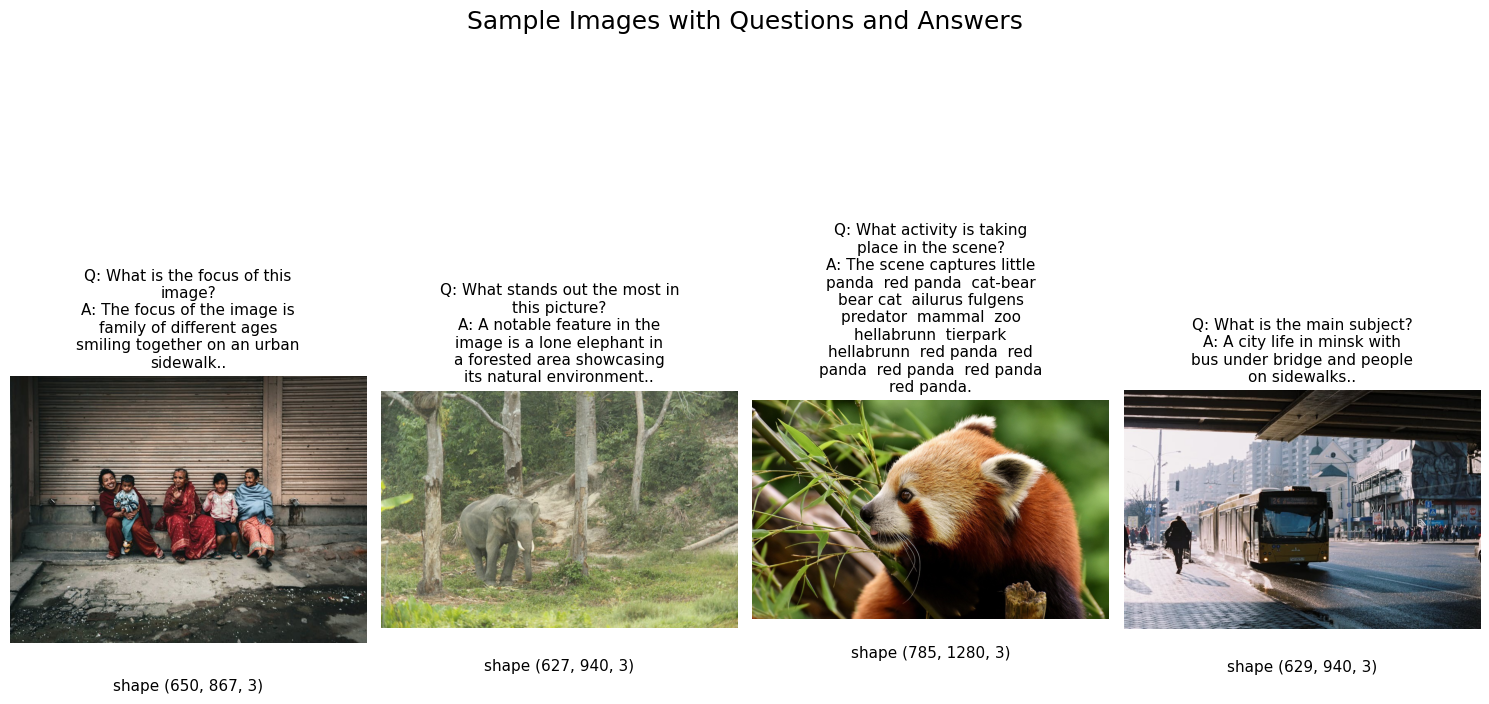

In [5]:
import cv2
import textwrap
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))

num_samples = 4
sample_df = df.sample(num_samples, random_state=101)

cols = 4
rows = 1

for i, (_, row) in enumerate(sample_df.iterrows()):
    img_path = row['image_path']
    question = str(row['question'])
    answer = str(row['answer'])

    img = cv2.imread(img_path)

    if img is None:
        print(f"Could not read image: {img_path}")
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    question = "\n".join(textwrap.wrap(question, width=28))
    answer = "\n".join(textwrap.wrap(answer, width=28))

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f"Q: {question}\nA: {answer}", fontsize=11)
    plt.text(
        0.5, -0.18, f"shape {img.shape}",
        fontsize=11,
        ha='center',
        transform=plt.gca().transAxes
    )
    plt.axis('off')

plt.suptitle("Sample Images with Questions and Answers", fontsize=18)
plt.tight_layout()
plt.show()

In [6]:
import re

def clean_question(x):
    x = str(x).lower().strip()
    x = re.sub(r"\s+", " ", x)
    x = re.sub(r"[^\w\s?]", "", x)
    return x.strip()

def clean_answer(x):
    x = str(x).lower().strip()
    x = re.sub(r"\s+", " ", x)
    x = re.sub(r"[^\w\s]", "", x)
    return x.strip()

df["question"] = df["question"].apply(clean_question)
df["answer"]   = df["answer"].apply(clean_answer)

In [7]:
import re
import pandas as pd

STOP_PHRASES = {
    "nature", "to travel", "travel", "landscape"
}

def normalize_text(text):
    text = str(text).lower().strip()
    text = text.replace("-", " ")
    text = re.sub(r"[^\w\s,]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text

def clean_keyword_caption(text, max_phrases=6):
    text = normalize_text(text)

    # split by comma first
    phrases = [p.strip() for p in text.split(",") if p.strip()]

    # لو مفيش commas واصلًا
    if len(phrases) == 1:
        phrases = [p.strip() for p in re.split(r"\s{2,}", text) if p.strip()]

    # remove unwanted generic phrases
    phrases = [p for p in phrases if p not in STOP_PHRASES]

    # remove exact duplicates while preserving order
    seen = set()
    unique_phrases = []
    for p in phrases:
        if p not in seen:
            unique_phrases.append(p)
            seen.add(p)

    # sort by length descending so longer useful phrases come first
    unique_phrases = sorted(unique_phrases, key=lambda x: (-len(x.split()), x))

    # remove phrases that are contained inside longer phrases
    filtered = []
    for p in unique_phrases:
        if not any(p != q and p in q for q in filtered):
            filtered.append(p)

    # keep only top useful phrases
    filtered = filtered[:max_phrases]

    # optional reorder more naturally by phrase length then original importance
    filtered = sorted(filtered, key=lambda x: len(x.split()), reverse=True)

    # build final cleaned caption
    result = "start " + " ".join(filtered) + " end"
    result = re.sub(r"\s+", " ", result).strip()
    return result

df["question"] = df["question"].apply(clean_keyword_caption)
df["answer"]   = df["answer"].apply(clean_keyword_caption)

In [8]:
import re

GENERIC_WORDS = {
    "nature", "environment", "world", "photography",
    "animal", "wild animal", "wildlife photography",
    "large", "mammal"
}

def clean_caption_tags(text, max_words=10):
    text = str(text).lower().strip()

    text = text.replace("start", "").replace("end", "").strip()
    text = text.replace("-", " ")
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    cleaned = []
    seen = set()

    for w in words:
        if w in GENERIC_WORDS:
            continue
        if w not in seen:
            cleaned.append(w)
            seen.add(w)

    cleaned = cleaned[:max_words]

    return "start " + " ".join(cleaned) + " end"

df["question"] = df["question"].apply(clean_caption_tags)
df["answer"]   = df["answer"].apply(clean_caption_tags)

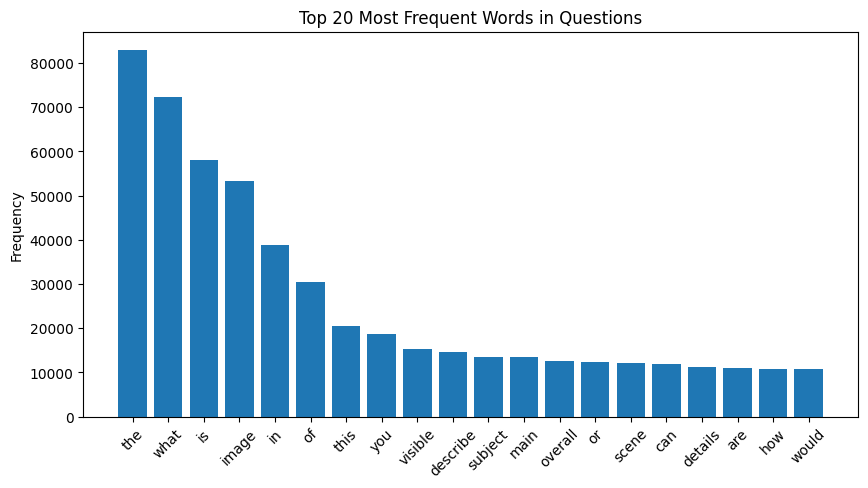

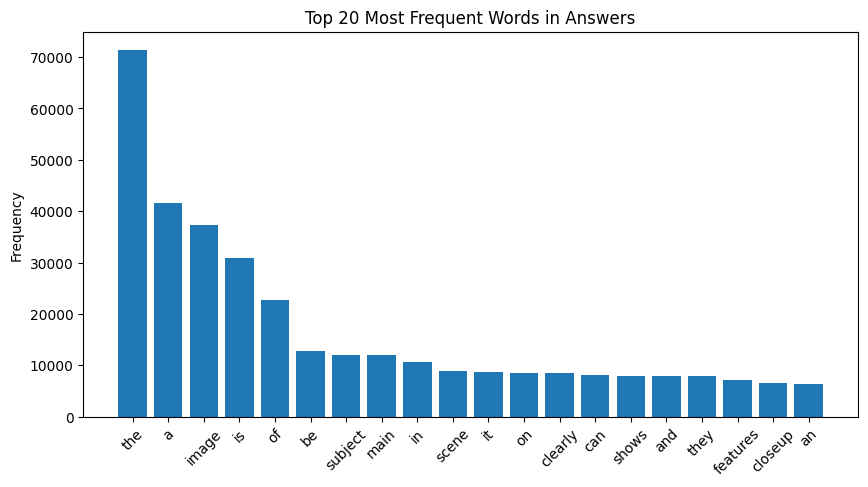

In [9]:
from collections import Counter
import matplotlib.pyplot as plt

# =========================
# Question words
# =========================
question_words = " ".join(df["question"].astype(str)).lower().split()
question_words = [w for w in question_words if w not in ["start", "end"]]

question_counts = Counter(question_words)
top_q = question_counts.most_common(20)

q_words = [w[0] for w in top_q]
q_counts = [w[1] for w in top_q]

# =========================
# Answer words
# =========================
answer_words = " ".join(df["answer"].astype(str)).lower().split()
answer_words = [w for w in answer_words if w not in ["start", "end"]]

answer_counts = Counter(answer_words)
top_a = answer_counts.most_common(20)

a_words = [w[0] for w in top_a]
a_counts = [w[1] for w in top_a]

# =========================
# Figure 1: Questions
# =========================
plt.figure(figsize=(10,5))
plt.bar(q_words, q_counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words in Questions")
plt.ylabel("Frequency")
plt.show()

# =========================
# Figure 2: Answers
# =========================
plt.figure(figsize=(10,5))
plt.bar(a_words, a_counts)
plt.xticks(rotation=45)
plt.title("Top 20 Most Frequent Words in Answers")
plt.ylabel("Frequency")
plt.show()

Question MAX LEN = 10
Answer   MAX LEN = 12


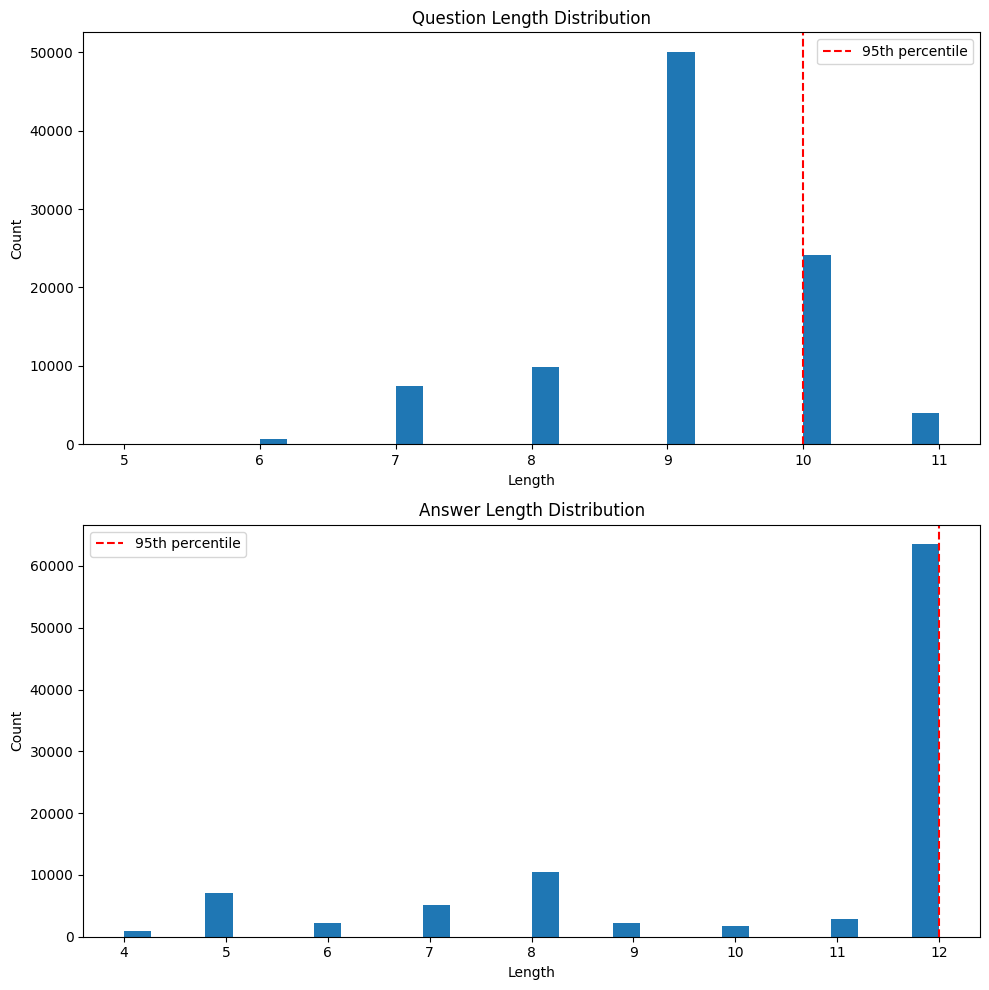

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# question lengths
q_lengths = df["question"].astype(str).apply(lambda x: len(x.split()))
Q_MAX_LEN = int(np.percentile(q_lengths, 95))

# answer lengths
a_lengths = df["answer"].astype(str).apply(lambda x: len(x.split()))
A_MAX_LEN = int(np.percentile(a_lengths, 95))

print(f"Question MAX LEN = {Q_MAX_LEN}")
print(f"Answer   MAX LEN = {A_MAX_LEN}")

plt.figure(figsize=(10, 10))

# Plot 1: Question
plt.subplot(2, 1, 1)
plt.hist(q_lengths, bins=30)
plt.axvline(np.percentile(q_lengths, 95), color='r', linestyle='--', label='95th percentile')
plt.title("Question Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.legend()

# Plot 2: Answer
plt.subplot(2, 1, 2)
plt.hist(a_lengths, bins=30)
plt.axvline(np.percentile(a_lengths, 95), color='r', linestyle='--', label='95th percentile')
plt.title("Answer Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.legend()

plt.tight_layout()
plt.show()

Question vocab size: 236
Answer vocab size: 6021


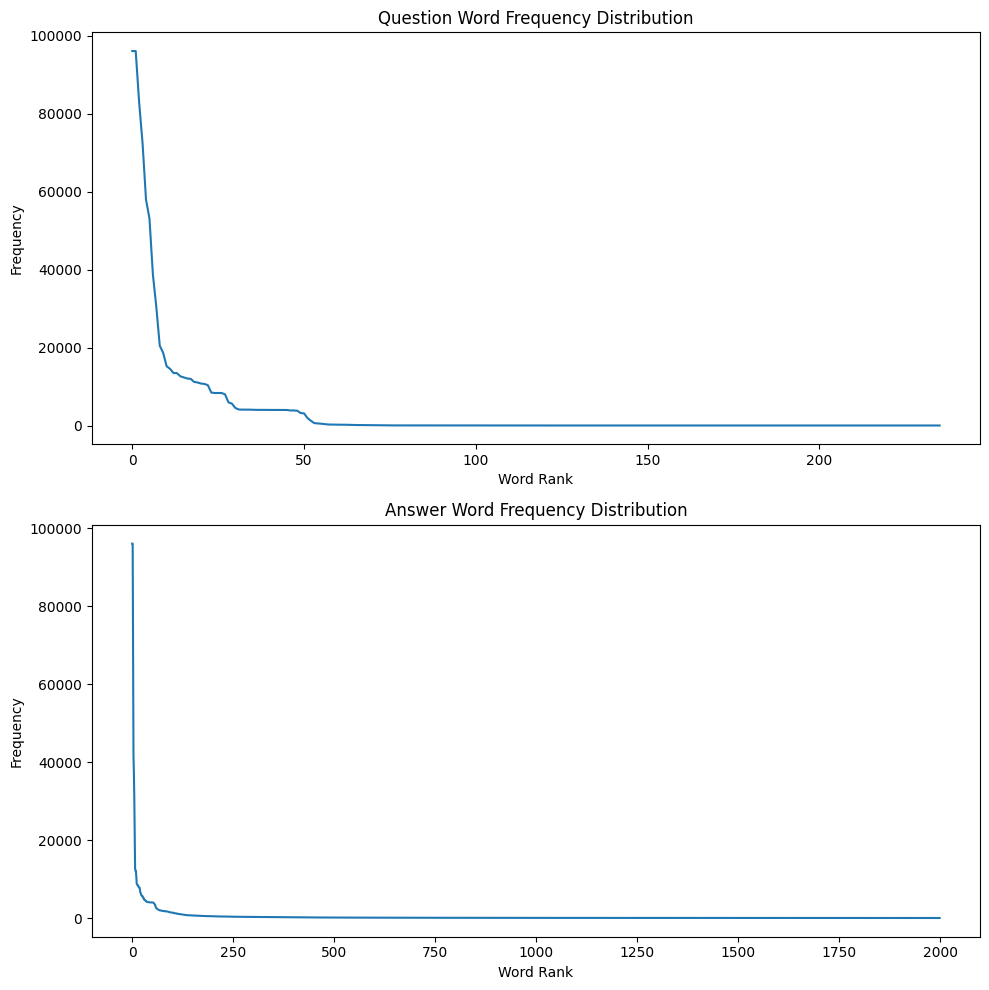

In [11]:
from collections import Counter
import matplotlib.pyplot as plt

# =========================
# Question
# =========================
q_words = " ".join(df["question"].astype(str)).split()
q_word_counts = Counter(q_words)
q_vocab_size = len(q_word_counts)
q_freqs = sorted(q_word_counts.values(), reverse=True)

# =========================
# Answer
# =========================
a_words = " ".join(df["answer"].astype(str)).split()
a_word_counts = Counter(a_words)
a_vocab_size = len(a_word_counts)
a_freqs = sorted(a_word_counts.values(), reverse=True)

print("Question vocab size:", q_vocab_size)
print("Answer vocab size:", a_vocab_size)

plt.figure(figsize=(10, 10))

# Plot 1: Question
plt.subplot(2, 1, 1)
plt.plot(q_freqs[:2000])
plt.title("Question Word Frequency Distribution")
plt.xlabel("Word Rank")
plt.ylabel("Frequency")

# Plot 2: Answer
plt.subplot(2, 1, 2)
plt.plot(a_freqs[:2000])
plt.title("Answer Word Frequency Distribution")
plt.xlabel("Word Rank")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [12]:
print(df["question"].str.split().str.len().describe())
print(df["answer"].str.split().str.len().describe())

print(df["answer"].value_counts().head(20))

count    96130.000000
mean         9.058254
std          0.940134
min          5.000000
25%          9.000000
50%          9.000000
75%         10.000000
max         11.000000
Name: question, dtype: float64
count    96130.000000
mean        10.432435
std          2.443502
min          4.000000
25%          8.000000
50%         12.000000
75%         12.000000
max         12.000000
Name: answer, dtype: float64
answer
start the setting is not clearly defined end                    4562
start it is an outdoor photo end                                3446
start they appear natural end                                   2436
start the theme is end                                          1525
start a woman end                                                207
start they appear end                                            194
start it can be inferred that the image shows closeup of end     170
start the theme is sport end                                     149
start the theme is transport 

In [13]:
df = df[df["answer"] != "the setting is not clearly defined"].reset_index(drop=True)

In [14]:
import pandas as pd
import re

def clean_answer(answer):
    answer = str(answer).lower().strip()

    prefixes = [
        "the main subject is a ", "the main subject is ",
        "it is an ", "it is a ", "it is ",
        "the environment shown includes ",
        "several visible details include ",
        "a notable feature in the image is ",
        "the photograph depicts ",
        "the image shows ", "the image features ",
        "the image clearly contains ",
        "the overall scene reflects ",
        "this image can be summarized as ",
        "the image conveys a sense of ",
        "they appear ", "they are ",
        "it appears to be ",
        "it can be inferred that the image shows ",
        "the focus of the image is ",
        "the scene captures ",
        "the image conveys ",
        "herd of cattle standing on green grass is the dominant color",
    ]

    for prefix in prefixes:
        if answer.startswith(prefix):
            answer = answer[len(prefix):]
            break

    words  = answer.split()
    seen   = {}
    result = []
    for w in words:
        seen[w] = seen.get(w, 0) + 1
        if seen[w] <= 2:
            result.append(w)

    return " ".join(result[:10])

df["answer"] = df["answer"].apply(clean_answer)



In [15]:
print(df[["image_path", "question", "answer", "caption"]].head(5).to_string())

                             image_path                                              question                                                                answer                                                                            caption
0  dataset_images/pexels_person_1_0.jpg           start what is the mans posture in image end                                     start he has his arms crossed end  grayscale portrait of a confident young man with crossed arms and a subtle smile.
1  dataset_images/pexels_person_1_0.jpg    start is the image in color or black and white end                   start the image is in grayscale black and white end  grayscale portrait of a confident young man with crossed arms and a subtle smile.
2  dataset_images/pexels_person_1_0.jpg         start what is the expression on mans face end                                       start he has a subtle smile end  grayscale portrait of a confident young man with crossed arms and a subtle smile.
3  dataset_i

In [16]:
print(df.columns.tolist())
print(len(df))

['image_path', 'image_url', 'source', 'topic', 'caption', 'question', 'answer']
96130


In [17]:
sample_img = df["image_path"].iloc[0]
print(df[df["image_path"] == sample_img][["question", "answer"]].to_string())

                                                    question                                                                   answer
0                start what is the mans posture in image end                                        start he has his arms crossed end
1         start is the image in color or black and white end                      start the image is in grayscale black and white end
2              start what is the expression on mans face end                                          start he has a subtle smile end
3       start how would you describe the mans appearance end                                 start he appears confident and young end
4         start what does the mans body language suggest end     start his crossed arms and subtle smile suggest confidence composure
48065  start what details can be observed in the picture end  start several visible details include grayscale portrait of a confident
48066              start what is the focus of this image end  

In [18]:
train_imgs = set(df["image_path"].values)

print(f"images: {len(df)}")

images: 96130


In [19]:
same_as_caption = df[df["answer"] == df["caption"]]
print(f"Rows where answer = caption: {len(same_as_caption)}")
print(f"Total rows: {len(df)}")

train_df_clean = df[df["answer"] != df["caption"]].reset_index(drop=True)


print(f"\nAfter cleaning:")
print(f"Train: {len(train_df_clean)}")

print("\nSample after cleaning:")
print(train_df_clean[["question", "answer"]].sample(10).to_string())

Rows where answer = caption: 0
Total rows: 96130

After cleaning:
Train: 96130

Sample after cleaning:
                                                    question                                                               answer
64507     start what stands out the most in this picture end           start a notable feature in the image is under construction
89301            start what can you infer from the scene end              start it can be inferred that the image shows streaming
95050           start what kind of is shown in the image end       start the shown includes elegant vintage wall clock mounted on
63628   start what activity is taking place in the scene end               start the scene captures a red stop sign stands amidst
23396        start what details are visible in the image end  start the image features a stunning chestnut horse galloping freely
21701        start what details are visible in the image end                      start the image features white and 

In [20]:
def clean_answer_v2(answer):
    answer = str(answer).lower().strip()
    
    # شيل التكرار
    words  = answer.split()
    seen   = {}
    result = []
    for w in words:
        seen[w] = seen.get(w, 0) + 1
        if seen[w] <= 2:
            result.append(w)
    
    return " ".join(result)

df["answer"] = df["answer"].apply(clean_answer_v2)


print(df["answer"].str.split().str.len().describe())

print(df[["question", "answer"]].sample(10).to_string())

count    96130.000000
mean         9.082576
std          1.626465
min          4.000000
25%          8.000000
50%         10.000000
75%         10.000000
max         10.000000
Name: answer, dtype: float64
                                                      question                                                          answer
84753              start what is the main subject of image end      start the main subject appears to be football soccer field
5253              start is this an indoor or outdoor photo end                                start it is an outdoor photo end
94753              start what can you infer from the scene end                 start it can be inferred that the image shows a
17636          start what details are visible in the image end  start the image features a tranquil white bench against sunlit
58659              start what is the main subject of image end      start the main subject appears to be train tracks zimbabwe
84254    start describe the overa

In [21]:
Q_MAX_LEN = 32
print("Q_MAX_LEN =", Q_MAX_LEN)
print("A_MAX_LEN =", A_MAX_LEN)

Q_MAX_LEN = 32
A_MAX_LEN = 12


In [22]:
from sklearn.model_selection import train_test_split

group_col = "image_path" if "image_path" in df.columns else "image_id"

unique_imgs = df[group_col].drop_duplicates()

train_imgs, temp_imgs = train_test_split(unique_imgs, test_size=0.2, random_state=42)
val_imgs, test_imgs   = train_test_split(temp_imgs, test_size=0.5, random_state=42)

train_df = df[df[group_col].isin(train_imgs)].reset_index(drop=True)
val_df   = df[df[group_col].isin(val_imgs)].reset_index(drop=True)
test_df  = df[df[group_col].isin(test_imgs)].reset_index(drop=True)

print(train_df.shape, val_df.shape, test_df.shape)

(76900, 7) (9610, 7) (9620, 7)


In [23]:
import tensorflow as tf

question_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=10000,
    output_mode="int",
    output_sequence_length=Q_MAX_LEN
)
question_vectorizer.adapt(train_df["question"])

answer_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=3000,
    output_mode="int",
    output_sequence_length=A_MAX_LEN
)
answer_vectorizer.adapt(train_df["answer"])

In [24]:
sample_question = train_df["question"].iloc[0]
sample_answer = train_df["answer"].iloc[0]

print("Original:")
print(sample_question)
print("\nVectorized:")
print(question_vectorizer([sample_question]))

print("Original:")
print(sample_answer)

print("\nVectorized:")
print(answer_vectorizer([sample_answer]))

Original:
start what color is the womans blouse end

Vectorized:
tf.Tensor(
[[  2   5  50   6   4  88 206   3   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0]], shape=(1, 32), dtype=int64)
Original:
start she is wearing a red blouse end

Vectorized:
tf.Tensor([[   2  551    6  142    4   57 1998    7    0    0    0    0]], shape=(1, 12), dtype=int64)


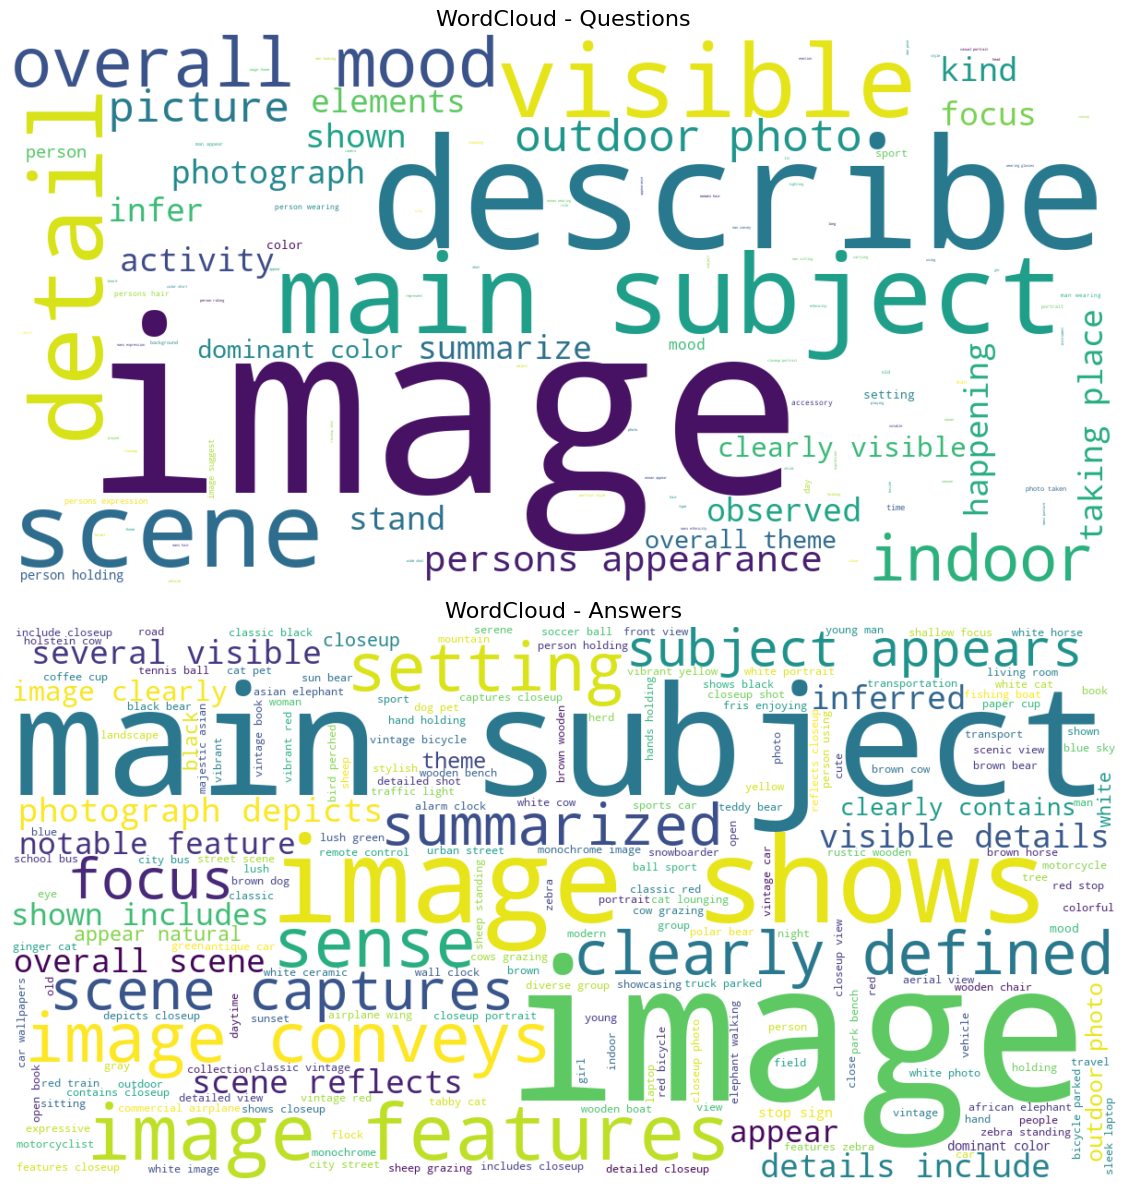

In [25]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

custom_stopwords = set(STOPWORDS)
custom_stopwords.update([
    "start", "end"
])

# question text
question_text = " ".join(train_df["question"].astype(str).tolist())

# answer text
answer_text = " ".join(train_df["answer"].astype(str).tolist())

question_wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords
).generate(question_text)

answer_wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=custom_stopwords
).generate(answer_text)

plt.figure(figsize=(15, 12))

# Plot 1: Questions
plt.subplot(2, 1, 1)
plt.imshow(question_wc, interpolation="bilinear")
plt.title("WordCloud - Questions", fontsize=16)
plt.axis("off")

# Plot 2: Answers
plt.subplot(2, 1, 2)
plt.imshow(answer_wc, interpolation="bilinear")
plt.title("WordCloud - Answers", fontsize=16)
plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
print(train_df["answer"].str.split().str.len().describe())
print(train_df["answer"].sample(5).values)

count    76900.000000
mean         9.084213
std          1.626325
min          4.000000
25%          8.000000
50%         10.000000
75%         10.000000
max         10.000000
Name: answer, dtype: float64
<ArrowStringArray>
[                                         'start the theme is end',
               'start the setting is sun bear relaxing on a stone',
     'start the photograph depicts a serene landscape of sheep in',
 'start the overall scene reflects a young man holding basketball',
       'start the image conveys a sense of brown elephant walking']
Length: 5, dtype: str


In [27]:
train_df.to_csv("train.csv", index=False)
val_df.to_csv("val.csv", index=False)
test_df.to_csv("test.csv", index=False)

In [28]:
import pickle

vocab = question_vectorizer.get_vocabulary()

with open("question_vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)
    
vocab = answer_vectorizer.get_vocabulary()

with open("answer_vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)